# ***Project Title: Flight Fare Prediction***

# ***1.Problem Statement***

Flight ticket prices can be something hard to guess, today we might see a price, check out the price of the same flight tomorrow, it will be a different story. We might have often heard travelers saying that flight ticket prices are so unpredictable. That’s why we will try to use machine learning to solve this problem. This can help airlines by predicting what prices they can maintain. 

### Objective

1) Analyze the flight fare dataset.
2) Clean and preprocess the data for machine learning.
3) Perform Exploratory Data Analysis.
4) Build different machine learning models for flight price prediction.
5) Compare the performance of different models using evaluation metrics.
6) Select the best model for accurate flight fare prediction.

# ***2.Data Description***

1) **Airline:**----   the types of airlines like Indigo, Jet Airways, Air India, and many more.
2) **Date_of_Journey:**----    The date on which the passenger starts the journey.
3) **Source:**----      This column holds the name of the place from where the passenger’s journey will start.
4) **Destination:**----     This column holds the name of the place to where passengers wanted to travel.
5) **Route:**----   The path the flight follows from the source to the destination, including any stopovers.
6) **Dep_Time:** The time at which the flight leaves from the source airport.
7) **Arrival_Time:**----     Arrival time is when the passenger will reach his/her destination.
8) **Duration:**----      The total time taken by the flight to complete the journey.
9) **Total_Stops:**----     This will let us know in how many places flights will stop there for the flight in the whole journey.
10) **Additional_Info:** ----     Extra information about the flight, such as meal availability or other services.
11) **Price:**----     Price of the flight for a complete journey including all the expenses before onboarding (Target Variable).


# ***3.Import Libraries***

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

# ***4.Load Dataset***

In [2]:
df= pd.read_csv("Flight_Fare.csv")

In [3]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR ? DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU ? IXR ? BBI ? BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL ? LKO ? BOM ? COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU ? NAG ? BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR ? NAG ? DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [4]:
df.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU ? BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU ? BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR ? DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR ? DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL ? GOI ? BOM ? COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [5]:
df.shape

(10683, 11)

In [6]:
print("Number of Rows:", df.shape[0])

Number of Rows: 10683


In [7]:
print("Number of Columns:", df.shape[1])

Number of Columns: 11


# ***5.Dataset Overview***

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [9]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


# ***6.Missing Values & Duplicates***

In [10]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [11]:
df.isnull().sum().sum()

np.int64(2)

In [12]:
df.duplicated().sum()

np.int64(220)

In [13]:
# Remove duplicates
df = df.drop_duplicates()

# ***7.Data Cleaning***

In [14]:
df.Route.unique()

array(['BLR ? DEL', 'CCU ? IXR ? BBI ? BLR', 'DEL ? LKO ? BOM ? COK',
       'CCU ? NAG ? BLR', 'BLR ? NAG ? DEL', 'CCU ? BLR',
       'BLR ? BOM ? DEL', 'DEL ? BOM ? COK', 'DEL ? BLR ? COK',
       'MAA ? CCU', 'CCU ? BOM ? BLR', 'DEL ? AMD ? BOM ? COK',
       'DEL ? PNQ ? COK', 'DEL ? CCU ? BOM ? COK', 'BLR ? COK ? DEL',
       'DEL ? IDR ? BOM ? COK', 'DEL ? LKO ? COK',
       'CCU ? GAU ? DEL ? BLR', 'DEL ? NAG ? BOM ? COK',
       'CCU ? MAA ? BLR', 'DEL ? HYD ? COK', 'CCU ? HYD ? BLR',
       'DEL ? COK', 'CCU ? DEL ? BLR', 'BLR ? BOM ? AMD ? DEL',
       'BOM ? DEL ? HYD', 'DEL ? MAA ? COK', 'BOM ? HYD',
       'DEL ? BHO ? BOM ? COK', 'DEL ? JAI ? BOM ? COK',
       'DEL ? ATQ ? BOM ? COK', 'DEL ? JDH ? BOM ? COK',
       'CCU ? BBI ? BOM ? BLR', 'BLR ? MAA ? DEL',
       'DEL ? GOI ? BOM ? COK', 'DEL ? BDQ ? BOM ? COK',
       'CCU ? JAI ? BOM ? BLR', 'CCU ? BBI ? BLR', 'BLR ? HYD ? DEL',
       'DEL ? TRV ? COK', 'CCU ? IXR ? DEL ? BLR',
       'DEL ? IXU ? BOM ? COK', 'CCU 

In [15]:
print(df["Route"].isnull().sum())

1


In [16]:
df.Total_Stops.unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', nan, '4 stops'],
      dtype=object)

In [17]:
print(df["Total_Stops"].isnull().sum())

1


In [18]:
df.dropna(inplace=True)

In [19]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

# ***8.Exploratory Data Analysis(EDA)***

In [20]:
# Airline Frequency
df["Airline"].value_counts()

Airline
Jet Airways                          3700
IndiGo                               2043
Air India                            1694
Multiple carriers                    1196
SpiceJet                              815
Vistara                               478
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

In [21]:
# Source Frequency
df["Source"].value_counts()

Source
Delhi       4345
Kolkata     2860
Banglore    2179
Mumbai       697
Chennai      381
Name: count, dtype: int64

In [22]:
# Destination Frequency
df["Destination"].value_counts()

Destination
Cochin       4345
Banglore     2860
Delhi        1265
New Delhi     914
Hyderabad     697
Kolkata       381
Name: count, dtype: int64

In [23]:
# Total Stops Frequency
df["Total_Stops"].value_counts()

Total_Stops
1 stop      5625
non-stop    3475
2 stops     1318
3 stops       43
4 stops        1
Name: count, dtype: int64

In [24]:
# Additional Info Frequency
df["Additional_Info"].value_counts()

Additional_Info
No info                         8182
In-flight meal not included     1926
No check-in baggage included     318
1 Long layover                    19
Change airports                    7
Business class                     4
No Info                            3
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

# **A) Univariate Analysis**

# 1) Airline Count Plot

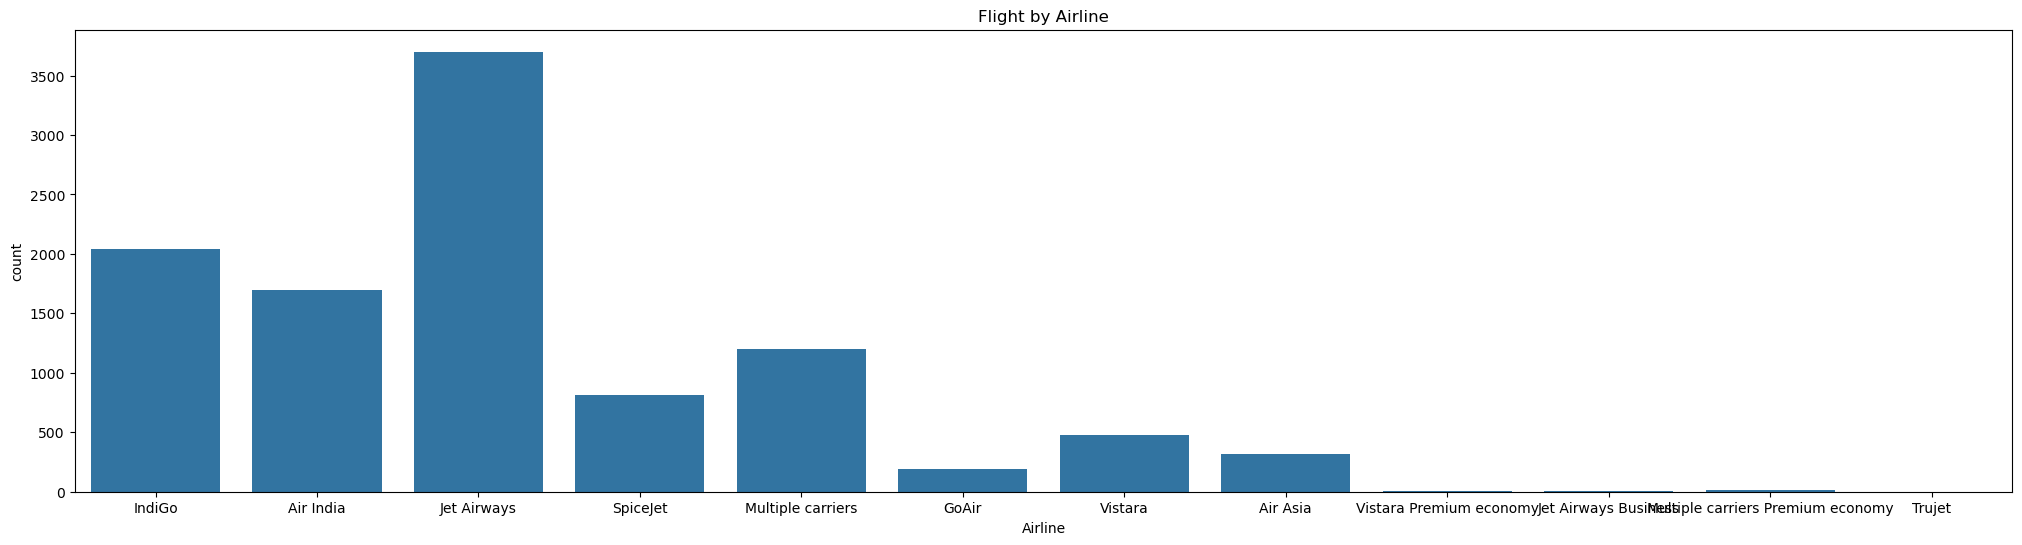

In [25]:
plt.figure(figsize=(25,6))

sns.countplot(x="Airline", data=df)
plt.title("Flight by Airline")
plt.show()

# Observation

1) The graph shows the number of flights.
2) Jet Airways has highest number of flights.
3) Some Airlines have very few flights.

# 2) Flight By Source

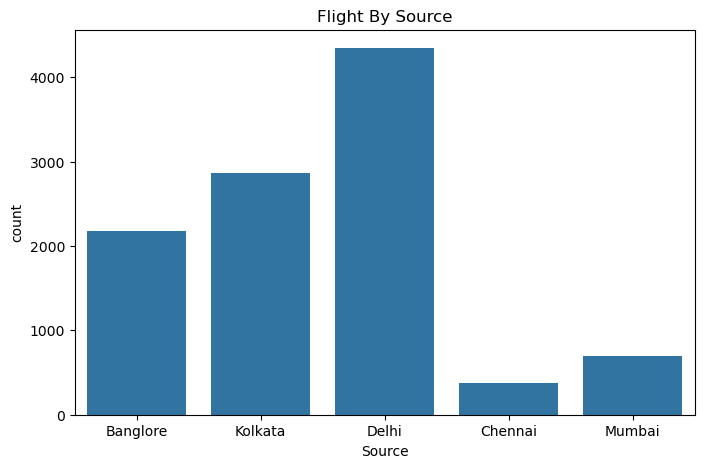

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(x="Source", data=df)
plt.title("Flight By Source")
plt.show()

# Observation

1) The chart Shows The number of flights from each source city.
2) Delhi has the highest number of flights.
3) Kolkata and Banglore have good number of flights.
4) Mumbai and Chennai have few flights as compare to other cities.


# 3) Flight By Destination

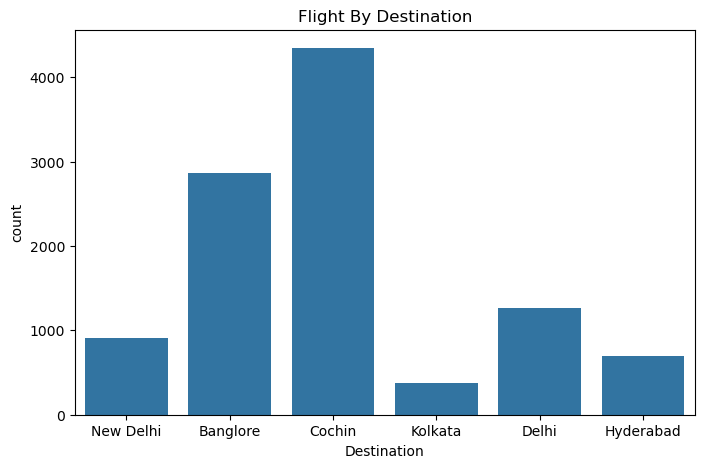

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(x="Destination", data=df)
plt.title("Flight By Destination")
plt.show()

# Observation

1) The chart shows the number of flights to each destination city.
2) Cochin has the hights number of flights.
3) Banglore also a large number of flights.
4) Hyderabad, New Delhi, and Kolkata have few flights compared to Cochin.

# 4) Flight By Total Stops

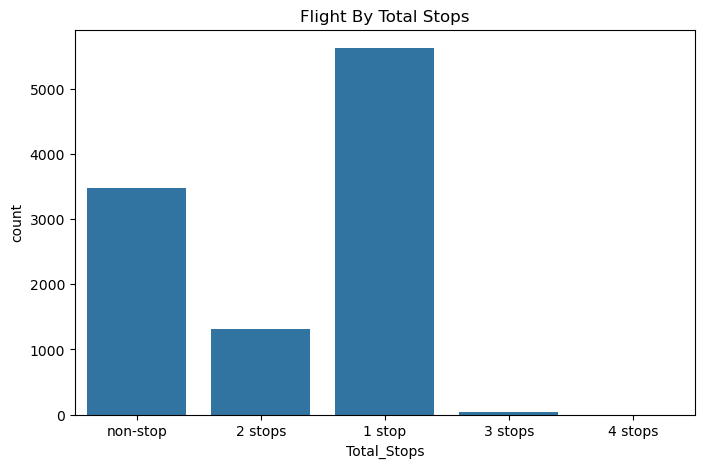

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(x="Total_Stops", data=df)
plt.title("Flight By Total Stops")
plt.show()

# Observation

1) The chart shhows the number of flights based on the total stops.
2) 1-stop flights have the highest number of records.
3) Non-stop flights are also available in large numbers.
4) Flights with 2,3, and 4 stops less number records.
5) Most passengers travel on flights with Non-stop and 1-stop.

# 5) Distribution Of Flight Price

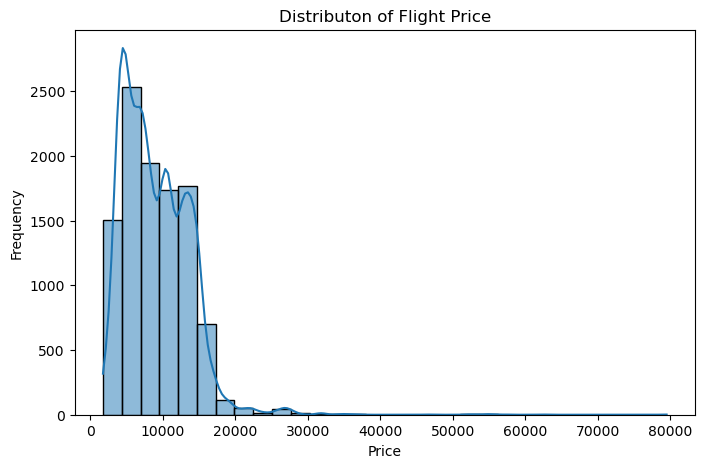

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(df["Price"], bins=30, kde=True)
plt.title("Distributon of Flight Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# Observation

1) The graph shows the distribution of flight ticket prices.
2) Most flights ticket prices are in the low to medium to price range.
3) The data is not normally distributed.
4) The distribution is right-skewed(Positive skewed).

# 6) Flight By Additional Info

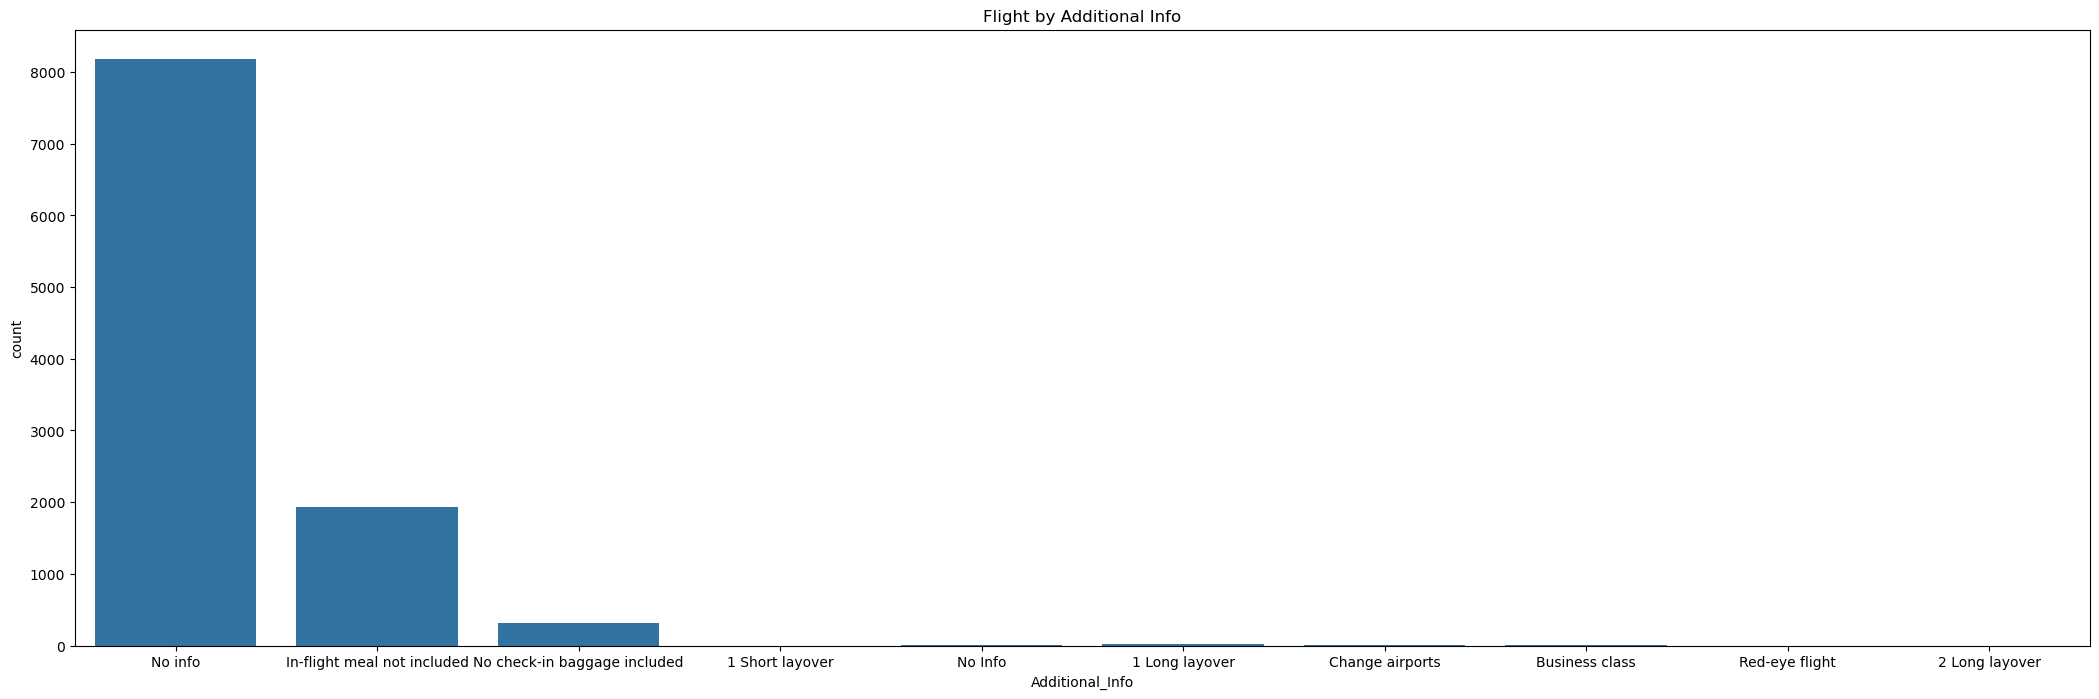

In [30]:
plt.figure(figsize=(26,8))

sns.countplot(x="Additional_Info", data=df)
plt.title("Flight by Additional Info")
plt.show()

# **B) Bivariate Analysis**

# 1) Flight Price by Airline

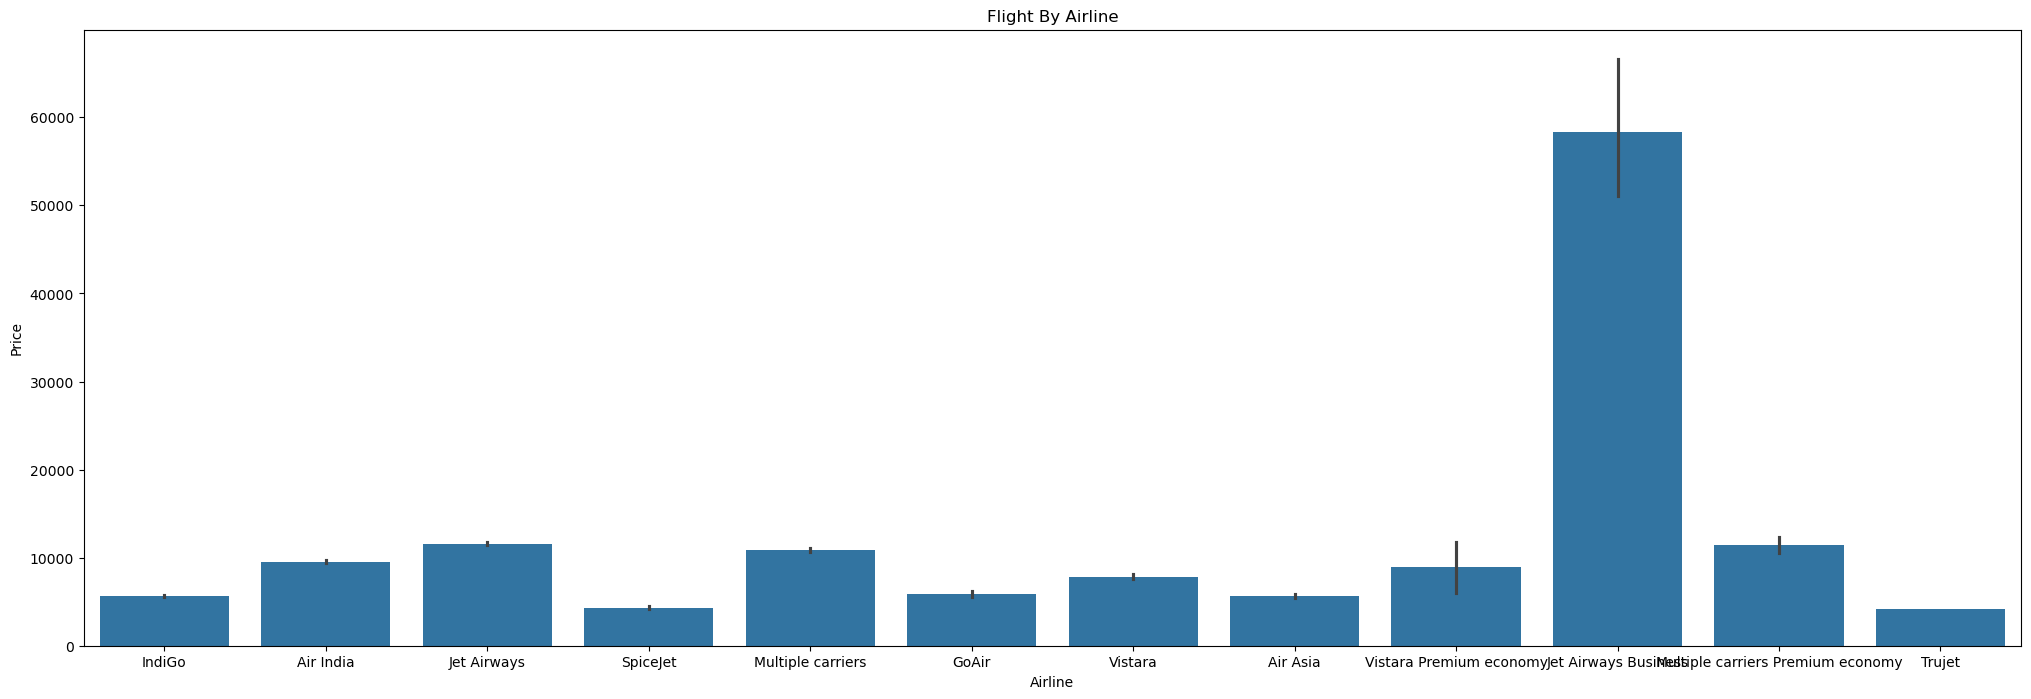

In [31]:
plt.figure(figsize=(25,8))

sns.barplot(x="Airline", y="Price", data=df)
plt.title("Flight By Airline")
plt.show()

# Observation

1) The chart shows the average flight ticket price for each airline.
2) Jet Airways Business has the highest ticket price.
3) Spicejet and Trujet have lower ticket price to other airlines.
4) Others airline flights are same range ticket price.

# 2) Flight Price by Source

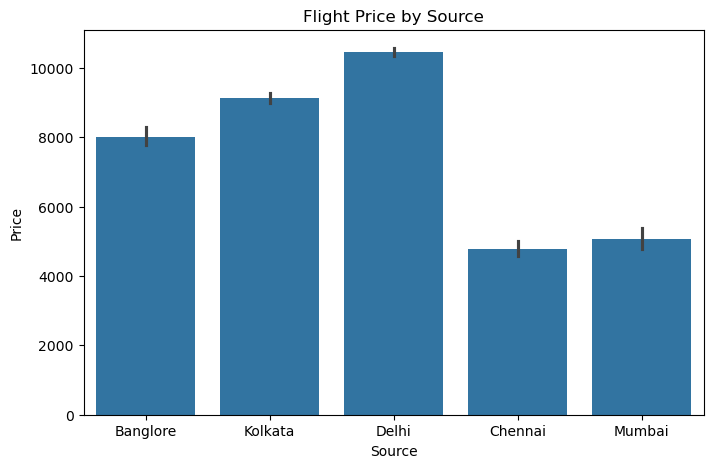

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(x="Source", y="Price", data=df)
plt.title("Flight Price by Source")
plt.show()

# Observation

1) The graph shows the flights ticket price from each source city.
2) Delhi has the highest flight price.
3) Mumbai and Chennai has the lowest flight price.

# 3) Flight Price by Destination

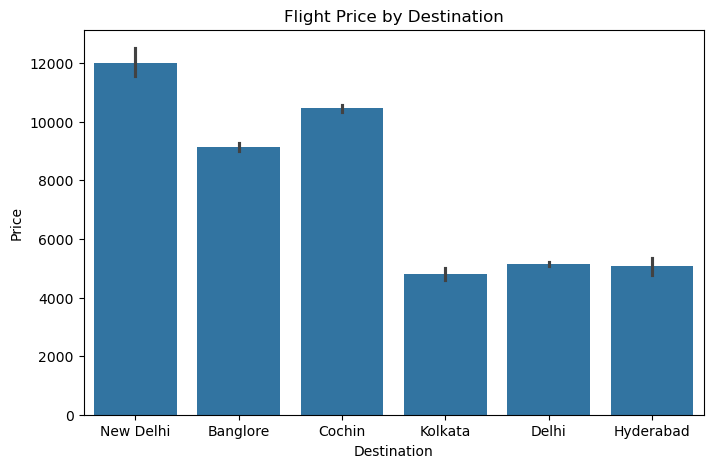

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(x="Destination", y="Price", data=df)
plt.title("Flight Price by Destination")
plt.show()

# Observation

1) The graph shows the flight ticket price for each destination city.
2) New Delhi has the hightest flights ticket price.
3) Banglore  and Cochin have moderate ticket price.
4) Kolkata, Delhi, Hyderabad have lower ticket prices.

# 4) Flight Price by Total Stops

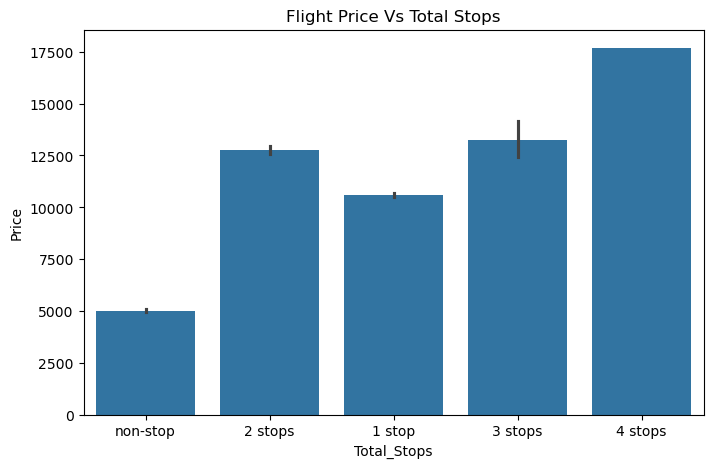

In [34]:
plt.figure(figsize=(8,5))

sns.barplot(x="Total_Stops", y="Price", data=df)
plt.title("Flight Price Vs Total Stops")
plt.show()

# Observation

1) The graph shows the flight ticket price based on the number of stops.
2) 4 stops flights have highest price.
3) non-stop flihts have lowest price.

# 5) Boxplot for Flight Price

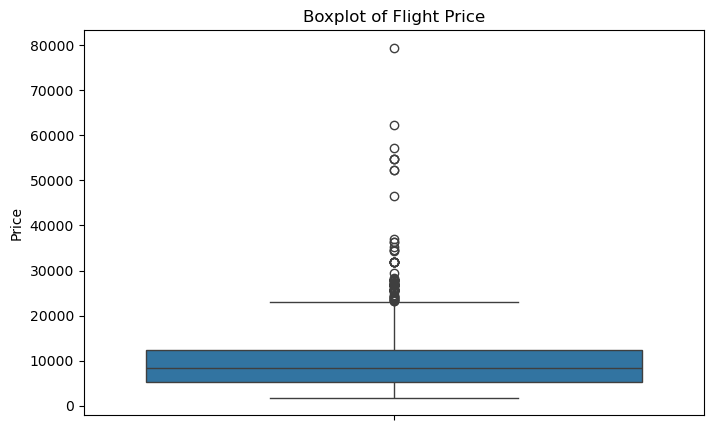

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df["Price"])
plt.title("Boxplot of Flight Price")
plt.show()

# Observation

1) The boxplot shows the distribution of flight ticket prices.
2) Ther are some outliers are present.


# 6) Airline Vs Price

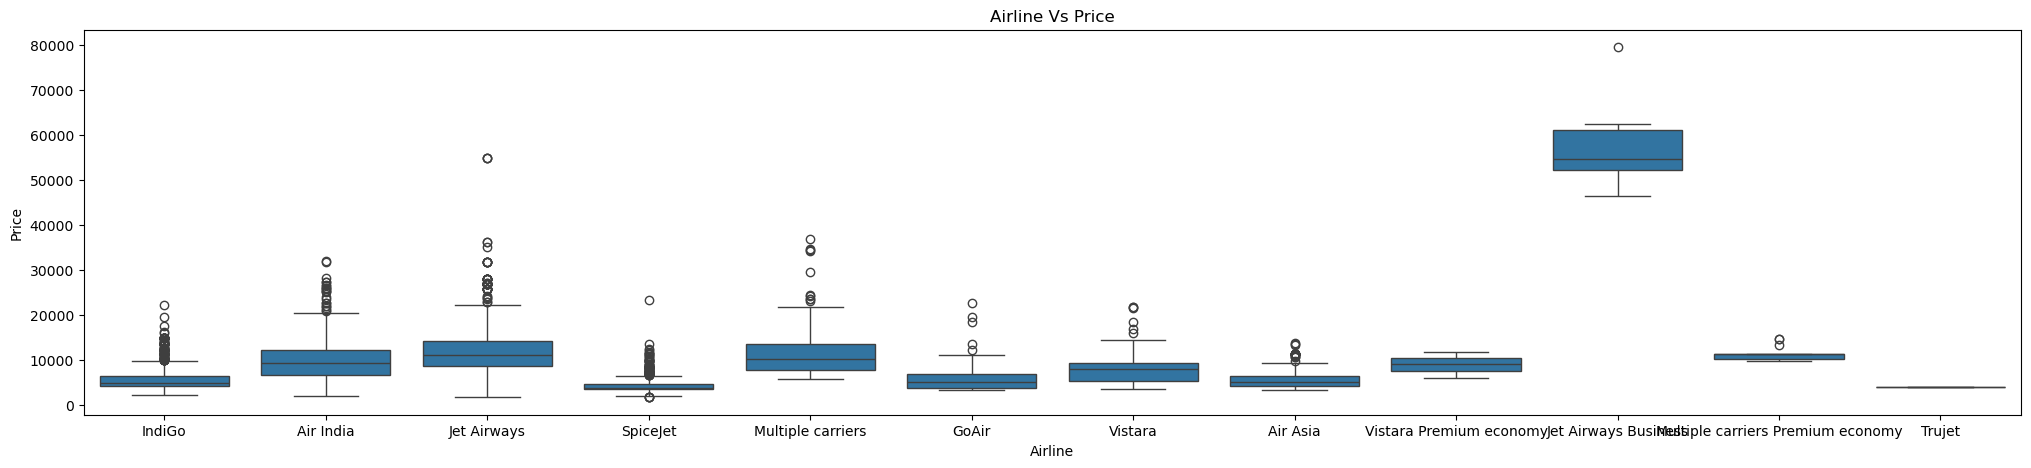

In [36]:
plt.figure(figsize=(25,5))

sns.boxplot(x="Airline", y="Price", data=df)
plt.title("Airline Vs Price")
plt.show()

# Observation

1) The graph shows the distribution of flight ticket price for each airline.
2) Different airline have different price range.
3) Some airline have higher ticket price.

# 7) Total Stops Vs Price

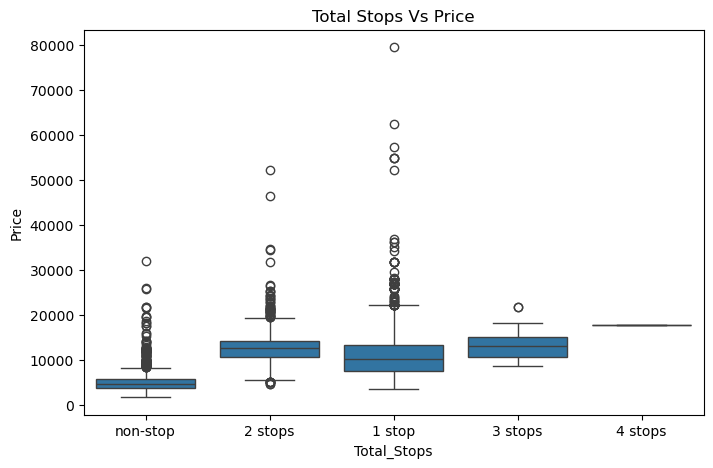

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Total_Stops", y="Price", data=df)
plt.title("Total Stops Vs Price")
plt.show()

# Observation

1) The boxplot shows the distribution of flight ticket price based on the number of stops.
2) 1-stop have higher ticket price.

# **C) Multivariate Analysis**

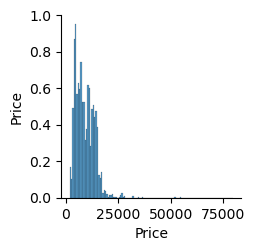

In [38]:
sns.pairplot(df[["Price"]])
plt.show()

# Observation

1) The pair plot shows the distribution of the price column.
2) A few flights have high ticket prices.
3) The distribution is right-skewed(positively skewed).

# ***Outlier Detection***

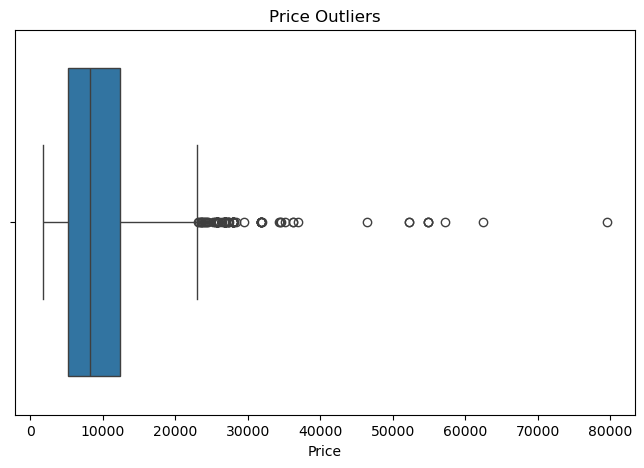

In [39]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Price"])
plt.title("Price Outliers")
plt.show()

# Airline-wise Average Price

In [40]:
df.groupby("Airline")["Price"].mean().sort_values(ascending=False)

Airline
Jet Airways Business                 58358.666667
Jet Airways                          11599.021081
Multiple carriers Premium economy    11418.846154
Multiple carriers                    10902.678094
Air India                             9556.608028
Vistara Premium economy               8962.333333
Vistara                               7801.355649
GoAir                                 5861.056701
IndiGo                                5668.469897
Air Asia                              5590.260188
SpiceJet                              4335.841718
Trujet                                4140.000000
Name: Price, dtype: float64

# Source-wise Average Price

In [41]:
df.groupby("Source")["Price"].mean().sort_values(ascending=False)

Source
Delhi       10461.600690
Kolkata      9143.083566
Banglore     8022.872877
Mumbai       5059.708752
Chennai      4789.892388
Name: Price, dtype: float64

# Destination-wise Average Price

In [42]:
df.groupby("Destination")["Price"].mean().sort_values(ascending=False)

Destination
New Delhi    12007.421225
Cochin       10461.600690
Banglore      9143.083566
Delhi         5143.918577
Hyderabad     5059.708752
Kolkata       4789.892388
Name: Price, dtype: float64

# Total Stops-wise Average Price

In [43]:
df.groupby("Total_Stops")["Price"].mean().sort_values(ascending=False)

Total_Stops
4 stops     17686.000000
3 stops     13260.674419
2 stops     12761.099393
1 stop      10594.123556
non-stop     5018.506763
Name: Price, dtype: float64

# ***9.Feature Engineering***

# 1) Date_of_Journey

In [44]:
df["Date_of_Journey"] = pd.to_datetime(
    df["Date_of_Journey"],
    dayfirst=True
)

df["Journey_Day"] = df["Date_of_Journey"].dt.day
df["Journey_Month"] = df["Date_of_Journey"].dt.month

In [45]:
df.drop("Date_of_Journey", axis=1, inplace=True)

# Observation

1) The Date_of_Journey column was converted into date format.
2) The day and month were extracted from the journey date.
3) These new columns help the model understand when the journey takes place.
4) The original Date_of_Journey column was removed because its information is already stored in Journey_Day and Journey_Month.

# 2) Departure Time

In [46]:
df["Dep_Time"] = pd.to_datetime(df["Dep_Time"])

In [47]:
df["Dep_Hour"] = df["Dep_Time"].dt.hour

df["Dep_Minute"] = df["Dep_Time"].dt.minute

In [48]:
df.drop("Dep_Time", axis=1, inplace=True)

# Observation

1) The Dep_Time column was converted into time format.
2) The departure hour and departure minute were extracted from the departure time.
3) These new features help the model understand the flight's departure time.
4) The original Dep_Time column was removed because its information is now stored in Dep_Hour and Dep_Minute.

# 3) Arrival_Time 

In [49]:
df["Arrival_Time"] = df["Arrival_Time"].str.split().str[0]

df["Arrival_Time"] = pd.to_datetime(
    df["Arrival_Time"],
    format="%H:%M"
)

In [50]:
df["Arrival_Hour"] = df["Arrival_Time"].dt.hour
df["Arrival_Minute"] = df["Arrival_Time"].dt.minute

In [51]:
df.drop("Arrival_Time", axis=1, inplace=True)

# Observation

1) The Arrival_Time column was cleaned by removing extra text.
2) The arrival time was converted into time format.
3) The arrival hour and arrival minute were extracted from the arrival time.
4) These new features help the model understand when the flight arrives.
5) The original Arrival_Time column was removed because its information is already stored in Arrival_Hour and Arrival_Minute.

# 4) Duration

In [52]:
duration = df["Duration"].str.replace("h"," ").str.replace("m"," ")

duration = duration.str.split(expand=True)

In [53]:
df["Duration_Hours"] = duration[0].fillna(0).astype(int)

In [54]:
df["Duration_Minutes"] = duration[1].fillna(0).astype(int)

In [55]:
df.drop("Duration", axis=1, inplace=True)

# Observations

1) The Duration column was cleaned by separating hours and minutes.
2) Two new columns, Duration_Hours and Duration_Minutes, were created.
3) These new features help the model understand the total flight duration more accurately.
4) The original Duration column was removed because its information is already stored in the new columns.

# 5) Total_Stops 

In [56]:
df["Total_Stops"].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [57]:
df["Total_Stops"] = df["Total_Stops"].replace({
    "non-stop":0,
    "1 stop":1,
    "2 stops":2,
    "3 stops":3,
    "4 stops":4
})

In [58]:
df.drop(["Route", "Additional_Info"], axis=1, inplace=True)

# Observation

1) The Total_Stops column was converted from text into numerical values.
2) This makes the data easier for the machine learning model to understand.
3) The Route and Additional_Info columns were removed because they were not needed for model training.

In [59]:
df.columns

Index(['Airline', 'Source', 'Destination', 'Total_Stops', 'Price',
       'Journey_Day', 'Journey_Month', 'Dep_Hour', 'Dep_Minute',
       'Arrival_Hour', 'Arrival_Minute', 'Duration_Hours', 'Duration_Minutes'],
      dtype='object')

# ***One-Hot Encoding***

In [60]:
le = LabelEncoder()

In [61]:
cat_cols = df.select_dtypes(include="object").columns

In [62]:
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# ***Correlation Heatmap***

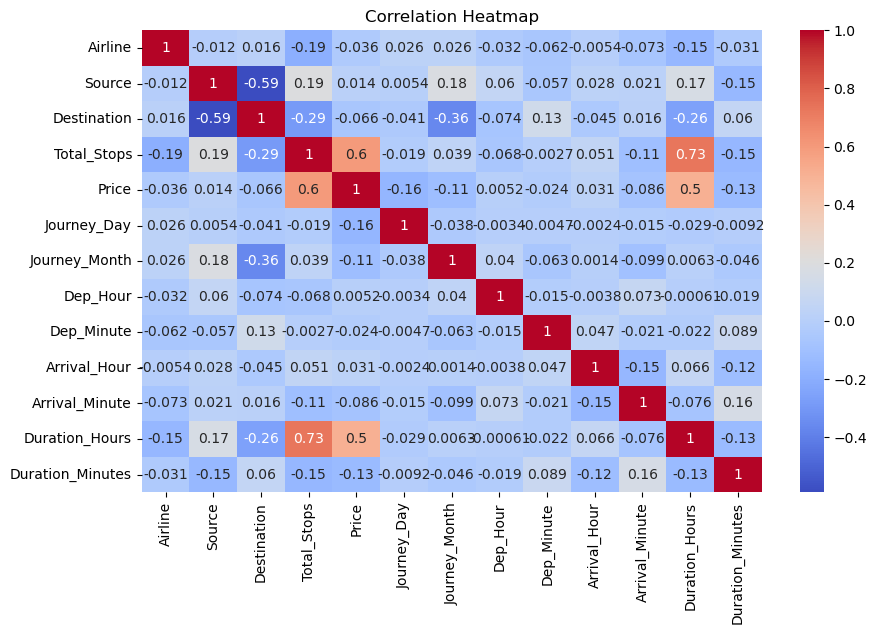

In [63]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()           

# ***10.Feature and Target Separation***

In [64]:
X=df.drop("Price", axis=1)
y=df["Price"]

# ***11.Train-Test Split***

In [65]:
X_train, X_test,y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# ***12.Feature Scaling***

In [66]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ***13.Model Building***

# 1) Linear Regression

In [67]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

# 2) Decision Tree

In [68]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train,y_train)

pred_dt = dt.predict(X_test)

# 3) Random Forest

In [69]:
rf = RandomForestRegressor( n_estimators=200,random_state=42)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

# ***14.Model Evaluation***

In [70]:
def evaluate_model(y_true,y_pred):

    mae = mean_absolute_error(y_true,y_pred)

    mse = mean_squared_error(y_true,y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true,y_pred)

    return mae,mse,rmse,r2

In [71]:
lr_result = evaluate_model(y_test,pred_lr)

dt_result = evaluate_model(y_test,pred_dt)

rf_result = evaluate_model(y_test,pred_rf)

# ***15.Model Comparision***

In [72]:
results = pd.DataFrame({
        "Model":[ "Linear Regression",
                  "Decision Tree",
                  "Random Forest"
                ],

    "MAE":[ lr_result[0],
            dt_result[0],
            rf_result[0]
           ],

    "MSE":[ lr_result[1],
            dt_result[1],
            rf_result[1]
           ],

    "RMSE":[ lr_result[2],
             dt_result[2],
             rf_result[2]
            ],

    "R2 Score":[ lr_result[3],
                 dt_result[3],
                 rf_result[3]
                ]
})

best_model = results.sort_values("R2 Score", ascending=False)

best_model

,Model,MAE,MSE,RMSE,R2 Score
2,Random Forest,1202.446140,4.212686e+06,2052.482877,0.797955
1,Decision Tree,1400.724439,6.295276e+06,2509.038818,0.698072
0,Linear Regression,2437.808177,1.153561e+07,3396.411849,0.446741


# ***16.Best Model***

In [73]:
best_model = results.sort_values("R2 Score", ascending=False).iloc[0]["Model"]

print(best_model)

Random Forest


# ***17.Cross Validation***

In [74]:
best_model = rf      

cv_scores = cross_val_score(
    estimator=best_model,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='r2'
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage R² Score:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross Validation Scores:
[0.77314227 0.81223491 0.82765729 0.80498739 0.79613259]

Average R² Score: 0.8028308887898312
Standard Deviation: 0.018087107386540718


# ***18.Hyperparameter Tuning***

In [75]:
param_grid = {'n_estimators': [100, 200, 300],
              'max_depth': [10, 20, 30, None],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 2, 4],
              'max_features': ['sqrt', 'log2']
             }

grid_search = GridSearchCV( estimator=RandomForestRegressor(random_state=42),
                            param_grid=param_grid,
                            scoring='r2',
                            cv=5,
                            n_jobs=-1,
                            verbose=2

)

grid_search.fit(X_train, y_train)

print("Best Parameters:\n")
print(grid_search.best_params_)
print("Best Cross Validation Score:")
print(grid_search.best_score_)

best_model = grid_search.best_estimator_

best_model

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters:

{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best Cross Validation Score:
0.8108438041208187


RandomForestRegressor(max_depth=20, max_features='sqrt', min_samples_split=5,
                      n_estimators=300, random_state=42)

# ***19.Residual Analysis***

In [76]:
y_pred = best_model.predict(X_test)

# Residuals
residuals = y_test - y_pred
residuals.head()

2150    2850.271269
3784      18.300854
714      147.995278
7558   -2448.743349
7413     533.356275
Name: Price, dtype: float64

# ***20.Residual Scatter Plot***

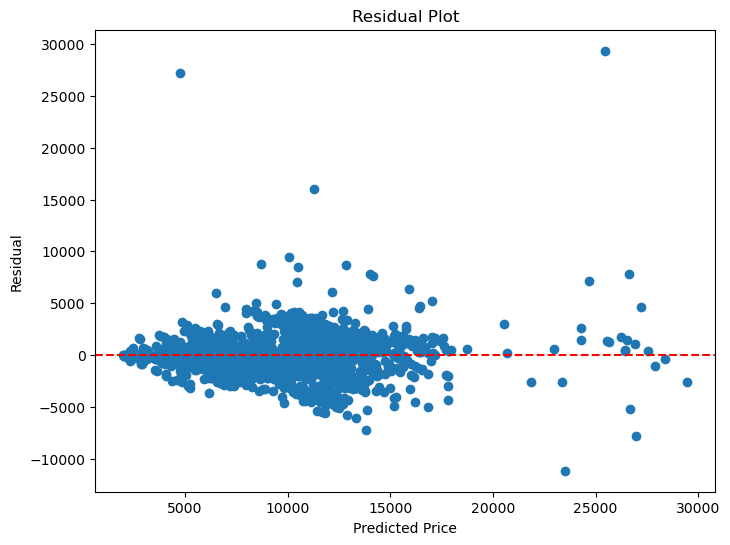

In [77]:
plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)
plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)
plt.title("Residual Plot")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.show()

# ***21.Residual Distribution***

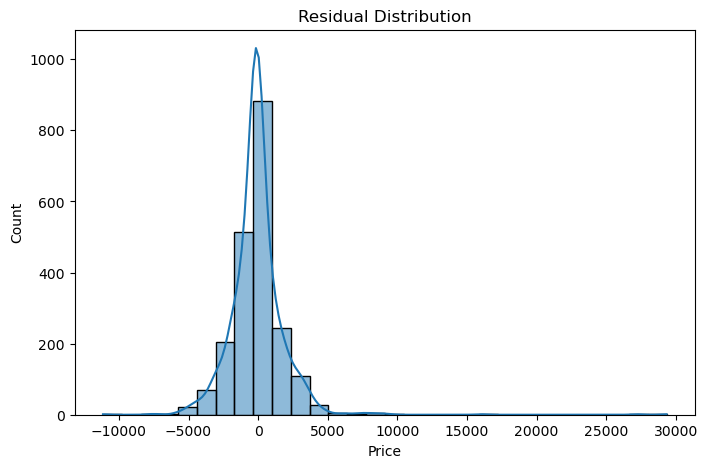

In [78]:
plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)
plt.title("Residual Distribution")
plt.show()

# ***22.Compare Actual vs Predicted Values***

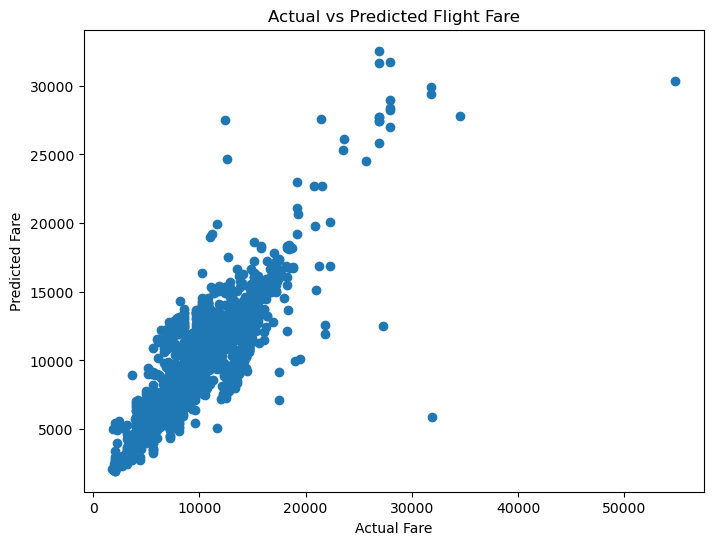

In [79]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, pred_rf)

plt.xlabel("Actual Fare")

plt.ylabel("Predicted Fare")

plt.title("Actual vs Predicted Flight Fare")

plt.show()

# ***23.Feature Importance***

In [80]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False,
    inplace=True
)

importance.head(10)

,Feature,Importance
10,Duration_Hours,0.445369
4,Journey_Day,0.155055
0,Airline,0.118278
3,Total_Stops,0.053139
5,Journey_Month,0.049297
2,Destination,0.039038
6,Dep_Hour,0.032452
8,Arrival_Hour,0.031760
7,Dep_Minute,0.024775
11,Duration_Minutes,0.022255


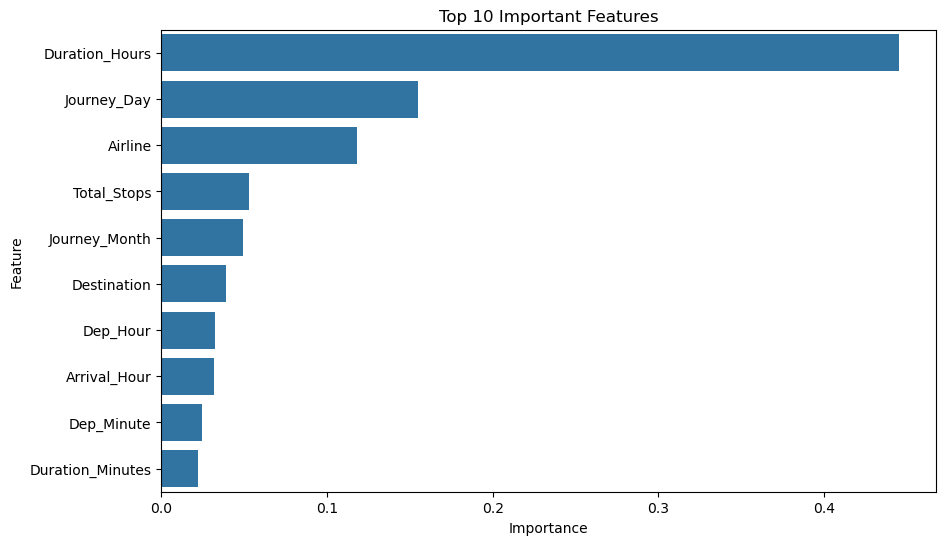

In [81]:
plt.figure(figsize=(10,6))

sns.barplot(x="Importance", y="Feature", data=importance.head(10))
plt.title("Top 10 Important Features")
plt.show()

# ***24.Challenges Faced***

1. Missing Values
- Some columns contained missing values.
- These rows were removed because they were very few and would not significantly affect the dataset.

2. Date and Time Features
- Machine learning models cannot directly use date and time values.
- Date, departure time, arrival time, and duration were converted into numerical features.

3. Categorical Data
- Columns such as Airline, Source, and Destination contained text values.
- One-Hot Encoding was used to convert them into numerical format.

4. Feature Selection
- Route and Additional_Info were removed because they provided limited useful information or contained redundant data.

5. Model Selection
- Three machine learning models were trained and compared.
- Random Forest achieved the best performance based on MAE, RMSE, and R² Score.

# ***25.Conclusion***

1) Successfully cleaned and preprocessed the flight dataset.
2) Performed Exploratory Data Analysis (EDA) to understand the data.
3) Applied feature engineering to improve model performance.
4) Built and compared three machine learning models:
  * Linear Regression
  * Decision Tree Regressor
  * Random Forest Regressor
5) Random Forest achieved the best performance based on evaluation metrics.